# Sales Forecasting — Full Pipeline
**Goal:** Predict daily (Revenue) and (COGS) for 2023-01-01 → 2024-07-01

**Strategy:**
1. Load & merge all available data sources into daily features
2. Feature engineering: calendar + lag/rolling + promotions + orders + web traffic + returns + reviews
3. XGBoost model with log-transform targets
4. Cross-validation (TimeSeriesSplit) → MAE, RMSE, R^2 per fold
5. Feature Importance + SHAP
6. Export submission

## 1 — Imports & Config

In [1]:
# Sử dụng những thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math

# Machine Learning
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dành cho phần SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed — run: pip install shap')
    
# For Kaggle environment, set DATA_DIR to the input folder; otherwise, use local 'data/' directory
warnings.filterwarnings('ignore')
sns.set_theme(style = 'whitegrid')
DATA_DIR = 'data/' 
print('Libraries loaded.')

Libraries loaded.


/opt/homebrew/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 — Load & Inspect Data

#### 2.1 Show all tables

In [2]:
# Tải dữ liệu từ các file CSV
all_files = [
    'customers','geography','inventory','order_items','orders',
    'payments','products','promotions','returns','reviews',
    'sales','shipments','web_traffic'
]

# Đọc tất cả file vào dictionary, và in ra shape + columns của từng file
data = {}
for f in all_files:
    path = DATA_DIR + f + '.csv'
    try:
        data[f] = pd.read_csv(path, low_memory = False)
        print(f'{f.upper():20s} {str(data[f].shape):12s} | cols: {data[f].columns.tolist()}')
    except FileNotFoundError:
        print(f'[SKIP] {f}.csv not found at {path}')

CUSTOMERS            (121930, 7)  | cols: ['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']
GEOGRAPHY            (39948, 4)   | cols: ['zip', 'city', 'region', 'district']
INVENTORY            (60247, 17)  | cols: ['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month']
ORDER_ITEMS          (714669, 7)  | cols: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
ORDERS               (646945, 8)  | cols: ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']
PAYMENTS             (646945, 4)  | cols: ['order_id', 'payment_method', 'payment_value', 'installments']
PRODUCTS             (2412, 8)    | cols: ['product_id', 'product_name', 'category', 

#### 2.2 Load key tables with proper dtypes

In [33]:
# Đọc các bảng chính với parse_date cho cái cột ngày tháng
sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates = ['Date'])
test = pd.read_csv(DATA_DIR + 'sample_submission.csv', parse_dates = ['Date'])
promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates = ['start_date','end_date'])
orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates = ['order_date'])
returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates = ['return_date'])
reviews = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates = ['review_date'])
web = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates = ['date'])

# Sắp xếp sales theo trình tự thời gian
sales = sales.sort_values('Date').reset_index(drop = True)

# In ra thông tin cơ bản về tập dữ liệu
print(f'Train: {sales["Date"].min().date()} to {sales["Date"].max().date()}  ({len(sales):,} rows)')
print(f'Test: {test["Date"].min().date()} to {test["Date"].max().date()}   ({len(test):,} rows)')
print(f'Orders: {len(orders):,} rows')
print(f'Returns: {len(returns):,} rows')
print(f'Reviews: {len(reviews):,} rows')
print(f'Web: {len(web):,} rows')

print('\nBaseline Revenue Stats:')
print(sales[['Revenue','COGS']].describe().round(2))

Train: 2012-07-04 to 2022-12-31  (3,833 rows)
Test: 2023-01-01 to 2024-07-01   (548 rows)
Orders: 646,945 rows
Returns: 39,939 rows
Reviews: 113,551 rows
Web: 3,652 rows

Baseline Revenue Stats:
           Revenue         COGS
count      3833.00      3833.00
mean    4286584.03   3695134.49
std     2624840.20   2219788.77
min      279813.94    236576.31
25%     2471088.82   2150580.23
50%     3647303.90   3161112.99
75%     5350877.20   4637293.92
max    20905271.35  16535857.67


## 3 — Feature Engineering

#### 3.1 Combine train + test

In [4]:
# Kết hợp train và test để dễ feature enginerring
train_base = sales.copy()
train_base['is_test'] = 0
test_base  = test[['Date']].copy()
test_base['is_test'] = 1
df = pd.concat([train_base, test_base], ignore_index=True)
df = df.sort_values('Date').reset_index(drop=True)
print(f'Combined df: {df.shape}')

Combined df: (4381, 4)


#### 3.2 Calendar features

In [5]:
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_month'] = df['Date'].dt.day
df['day_of_year'] = df['Date'].dt.dayofyear
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['quarter'] = df['Date'].dt.quarter
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int) # Payday window: 25-31 and 1-5 of each month
# Thường sẽ tăng khả năng chi tiêu
df['is_payday_window'] = ((df['day_of_month'] >= 25) | (df['day_of_month'] <= 5)).astype(int)
# Các ngày lễ giảm giá dịp đặc biệt vd (1/1, 2/2 ...)
df['is_double_day']    = (df['month'] == df['day_of_month']).astype(int)
# Linear trend: ngày từ khi bắt đầu
df['days_since_start'] = (df['Date'] - df['Date'].min()).dt.days
print('Calendar features added.')

Calendar features added.


#### 3.3 Promotion features


Chức năng này tạo ra nhằm để chuyển từ bảng khuyến mãi sang các dữ liệu tổng hợp hàng ngày và bên trong bao gồm: Số lượng khuyến mãi vần còn hoạt động, mức giảm tối đa, và stackable_flag () 

In [6]:
# Tạo bảng hàng ngày để bao quát toàn thể các ngày
promo_range = pd.date_range(df['Date'].min(), df['Date'].max())
daily_p = pd.DataFrame({
    'Date': promo_range,
    'is_promo': 0, 'max_disc': 0.0, 'n_promos': 0,
    'is_stackable': 0, 'is_online': 0, 'is_email': 0, 'is_all_channels': 0
})
# Cho mỗi khuyến mãi, đánh dấu các ngày áp dụng khuyến mãi và cập nhật cho các cột tương ứng
for _, row in promotions.iterrows():
    mask = (daily_p['Date'] >= row['start_date']) & (daily_p['Date'] <= row['end_date'])
    daily_p.loc[mask, 'is_promo'] = 1
    daily_p.loc[mask, 'n_promos'] += 1
    if row['promo_type'] == 'percentage':
        daily_p.loc[mask, 'max_disc'] = np.maximum(daily_p.loc[mask, 'max_disc'], row['discount_value'])
    if row['stackable_flag']:
        daily_p.loc[mask, 'is_stackable'] = 1
    ch = row['promo_channel']
    if ch == 'online': daily_p.loc[mask, 'is_online'] = 1
    elif ch == 'email': daily_p.loc[mask, 'is_email'] = 1
    elif ch == 'all_channels': daily_p.loc[mask, 'is_all_channels'] = 1
df = df.merge(daily_p, on = 'Date', how = 'left').fillna(0)
print('Promotion features added.')

Promotion features added.


#### 3.4 Daily Orders features

Aggregate từ 'orders.csv': số đơn, tỉ lệ delivered/returned/cancelled, tỉ lệ mobile, tỉ lệ credit card.

In [7]:
daily_orders = orders.groupby('order_date').agg(
    n_orders =('order_id', 'count'),
    n_delivered = ('order_status', lambda x:(x == 'delivered').sum()),
    n_returned = ('order_status', lambda x:(x == 'returned').sum()),
    n_cancelled = ('order_status', lambda x:(x == 'cancelled').sum()),
    n_mobile = ('device_type', lambda x:(x == 'mobile').sum()),
    n_credit =('payment_method',lambda x:(x == 'credit_card').sum()),
).reset_index().rename(columns={'order_date': 'Date'})

daily_orders['pct_delivered'] = daily_orders['n_delivered'] / daily_orders['n_orders']
daily_orders['pct_returned'] = daily_orders['n_returned']  / daily_orders['n_orders']
daily_orders['pct_cancelled'] = daily_orders['n_cancelled'] / daily_orders['n_orders']
daily_orders['pct_mobile'] = daily_orders['n_mobile'] / daily_orders['n_orders']
daily_orders['pct_credit'] = daily_orders['n_credit'] / daily_orders['n_orders']

df = df.merge(daily_orders, on='Date', how='left')
print('Order features added. Shape:', df.shape)

Order features added. Shape: (4381, 33)


#### 3.5 Daily Returns features

Số lượt return và tổng refund mỗi ngày từ "returns.csv"

In [8]:
daily_returns = returns.groupby('return_date').agg(
    n_returns = ('return_id', 'count'),
    refund_total = ('refund_amount','sum'),
).reset_index().rename(columns = {'return_date': 'Date'})

df = df.merge(daily_returns, on = 'Date', how = 'left')
df[['n_returns','refund_total']] = df[['n_returns','refund_total']].fillna(0)
print('Return features added.')

Return features added.


#### 3.6 Daily Reviews features

Rating trung bình và số reviews mỗi ngày từ "reviews.csv" — proxy cho customer sentiment.
Có thể k ảnh hưởng đến main của revenue

In [9]:
daily_reviews = reviews.groupby('review_date').agg(
    avg_rating = ('rating','mean'),
    n_reviews  = ('rating','count'),
).reset_index().rename(columns = {'review_date': 'Date'})

df = df.merge(daily_reviews, on = 'Date', how = 'left')
df[['avg_rating','n_reviews']] = df[['avg_rating','n_reviews']].fillna(df[['avg_rating','n_reviews']].median())
print('Review features added.')

Review features added.


#### 3.7 Daily Web Traffic features

Sessions, visitors, bounce rate, session duration từ `web_traffic.csv`. Web traffic có từ 2013-01-01 nên các ngày trước đó sẽ được fill bằng median.

In [10]:
daily_web = web.groupby('date').agg(
    total_sessions = ('sessions', 'sum'),
    total_visitors = ('unique_visitors', 'sum'),
    avg_bounce = ('bounce_rate', 'mean'),
    avg_duration = ('avg_session_duration_sec', 'mean'),
).reset_index().rename(columns={'date': 'Date'})

df = df.merge(daily_web, on = 'Date', how = 'left')
web_cols = ['total_sessions','total_visitors','avg_bounce','avg_duration']
df[web_cols] = df[web_cols].fillna(df[web_cols].median())
print('Web traffic features added.')

Web traffic features added.


#### 3.8 Lag & Rolling Window features

Feature quan trọng nhất cho time-series:
- **Lag**: Revenue/COGS của 1, 7, 14, 30 ngày trước
- **Rolling mean/std**: 7, 14, 30 ngày


In [ ]:
for lag in [1, 7, 14, 30]:
    df[f'rev_lag_{lag}'] = df['Revenue'].shift(lag)
    df[f'cogs_lag_{lag}'] = df['COGS'].shift(lag)

for w in [7, 14, 30]:
    df[f'rev_roll_mean_{w}'] = df['Revenue'].shift(1).rolling(w).mean()
    df[f'rev_roll_std_{w}'] = df['Revenue'].shift(1).rolling(w).std()
    df[f'cogs_roll_mean_{w}'] = df['COGS'].shift(1).rolling(w).mean()

print('Lag & rolling features added.')
print(f'Total columns in df: {df.shape[1]}')

Lag & rolling features added.
Total columns in df: 58


## 4 — Prepare Train / Test Sets

In [47]:
FEATURES = [
    # Calendar
    'day_of_week','day_of_month','day_of_year','month','year',
    'quarter','week_of_year','is_weekend','is_payday_window',
    'is_double_day','days_since_start',
    # Promotions
    'is_promo','max_disc','n_promos','is_stackable',
    'is_online','is_email','is_all_channels',
    # Orders
    'n_orders','pct_delivered','pct_returned','pct_cancelled',
    'pct_mobile','pct_credit',
    # Returns
    'n_returns','refund_total',
    # Reviews
    'avg_rating','n_reviews',
    # Web traffic
    'total_sessions','total_visitors','avg_bounce','avg_duration',
    # Lag
    'rev_lag_1','rev_lag_7','rev_lag_14','rev_lag_30',
    'cogs_lag_1','cogs_lag_7','cogs_lag_14','cogs_lag_30',
    # Rolling
    'rev_roll_mean_7','rev_roll_std_7',
    'rev_roll_mean_14','rev_roll_std_14',
    'rev_roll_mean_30','cogs_roll_mean_7',
    'cogs_roll_mean_14','cogs_roll_mean_30',
]

train_df = df[df['is_test'] == 0].copy()
test_df  = df[df['is_test'] == 1].copy()

train_df['target_rev'] = np.log1p(train_df['Revenue'])
train_df['target_cogs'] = np.log1p(train_df['COGS'])

# Drop NaN rows from lag warm-up period
train_clean = train_df.dropna(subset=FEATURES).copy()

X_train = train_clean[FEATURES]
y_rev   = train_clean['target_rev']
y_cogs  = train_clean['target_cogs']
X_test  = test_df[FEATURES].fillna(0)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'Dropped  (NaN lag warm-up): {len(train_df) - len(train_clean)} rows')

X_train: (3803, 48)
X_test: (548, 48)
Dropped  (NaN lag warm-up): 30 rows


## 5 — Cross-Validation với TimeSeriesSplit

Dùng (TimeSeriesSplit) để mỗi fold validation luôn là future so với train.
KFold thông thường gây data leakage.

In [49]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

MODEL_PARAMS = {
    # Số lượng estimators đủ dùng và không quá lâu
    'n_estimators': 2000,

     # Tốc độ học và kiểm soát overfitting
    'learning_rate': 0.08,

    # Độ sâu cây vừa phải để tránh overfitting
    'max_depth': 6, 

    # Lấy mẫu ngầu nhiên 80% dữ liệu làm tăng tính đa dạng và giảm overfitting
    'subsample': 0.8, 

    # Tỷ lệ cột cũng 70% để giảm sự tương đồng giữa các cây
    'colsample_bytree': 0.7,

    # Dùng để tại lập kết quả
    'random_state': 42,

    # Sử dụng phương pháp cây histogram để tăng tốc độ và giảm bộ nhớ
    'tree_method': 'hist', 

    # đổi sang 'cpu' nếu không có GPU
    'device': 'cuda', 

    # Dừng trong trường hợp MAE không cải thiện sau 50 rounds để tránh overfitting
    'early_stopping_rounds': 50,

    # Chỉ số đánh giá trên validation, dùng MAE vì nó phù hợp với bài toán dự đoán doanh thu và được đề bài yêu cầu
    'eval_metric': 'mae',
}

# Công thức đúng theo đề bài:
# MAE  = (1/n) * sum(|F_i - A_i|)          → thấp hơn = tốt hơn
# RMSE = sqrt((1/n) * sum((F_i - A_i)^2))  → thấp hơn = tốt hơn
# R²   = 1 - sum((A_i-F_i)^2)/sum((A_i-Ā)^2)  → cao hơn = tốt hơn (lý tưởng ~1)

def compute_metrics(actual, preds):
    n = len(actual)
    mae = np.sum(np.abs(preds - actual)) / n
    rmse = np.sqrt(np.sum((preds - actual) ** 2) / n)
    ss_res = np.sum((actual - preds) ** 2)
    ss_tot = np.sum((actual - actual.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return mae, rmse, r2

cv_results = []
print(f'Running {N_SPLITS}-fold TimeSeriesSplit CV...')
print('-' * 70)
print(f'{"Fold":>4} | {"Train":>8} | {"Val":>6} | {"MAE (Rev)":>14} | {"RMSE (Rev)":>12} | {"R² (Rev)":>9}')
print('-' * 70)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_rev.iloc[tr_idx],   y_rev.iloc[val_idx]

    m = XGBRegressor(**MODEL_PARAMS)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    preds  = np.expm1(m.predict(X_val))
    actual = np.expm1(y_val).values

    mae, rmse, r2 = compute_metrics(actual, preds)
    cv_results.append({'fold': fold, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f'{fold:>4} | {len(X_tr):>8,} | {len(X_val):>6,} | {mae:>14,.0f} | {rmse:>12,.0f} | {r2:>9.4f}')

print('-' * 70)
cv_df = pd.DataFrame(cv_results)
print(f'{"MEAN":>4} | {"":>8} | {"":>6} | {cv_df["MAE"].mean():>14,.0f} | {cv_df["RMSE"].mean():>12,.0f} | {cv_df["R2"].mean():>9.4f}')
print(f'{"STD":>4} | {"":>8} | {"":>6} | {cv_df["MAE"].std():>14,.0f} | {cv_df["RMSE"].std():>12,.0f} | {cv_df["R2"].std():>9.4f}')

Running 5-fold TimeSeriesSplit CV...
----------------------------------------------------------------------
Fold |    Train |    Val |      MAE (Rev) |   RMSE (Rev) |  R² (Rev)
----------------------------------------------------------------------
   1 |      638 |    633 |        442,468 |      637,583 |    0.9393
   2 |    1,271 |    633 |        635,817 |    1,008,038 |    0.8972
   3 |    1,904 |    633 |        416,575 |      606,328 |    0.9510
   4 |    2,537 |    633 |        303,618 |      428,998 |    0.9239
   5 |    3,170 |    633 |        353,332 |      505,939 |    0.9034
----------------------------------------------------------------------
MEAN |          |        |        430,362 |      637,377 |    0.9229
 STD |          |        |        127,029 |      223,076 |    0.0229


#### 5.1 Visualise Cross-Validation scores

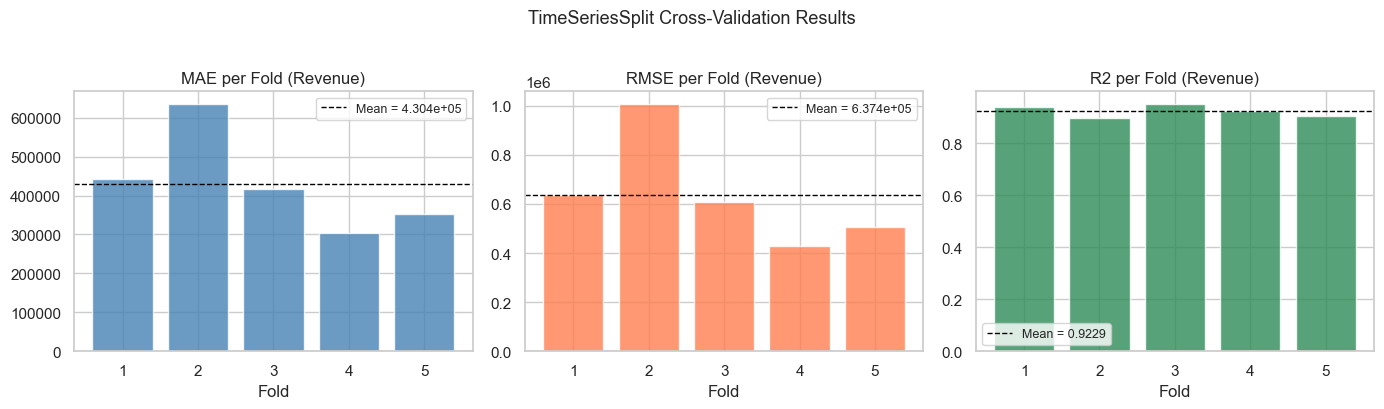

In [50]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4))
colors = ['steelblue', 'coral', 'seagreen']
for ax, metric, color in zip(axes, ['MAE','RMSE','R2'], colors):
    ax.bar(cv_df['fold'], cv_df[metric], color = color, alpha = 0.8, edgecolor='white')
    ax.axhline(cv_df[metric].mean(), color = 'black', linestyle = '--', linewidth = 1, label = f'Mean = {cv_df[metric].mean():.4g}')
    ax.set_title(f'{metric} per Fold (Revenue)', fontsize = 12)
    ax.set_xlabel('Fold')
    ax.legend(fontsize = 9)
plt.suptitle('TimeSeriesSplit Cross-Validation Results', fontsize = 13, y = 1.02)
plt.tight_layout()
plt.show()

## 6 — Train Final Models on Full Train Data

In [51]:
print('Training final XGBoost — Revenue...')
model_rev = XGBRegressor(**MODEL_PARAMS)
model_rev.fit(X_train, y_rev, eval_set = [(X_train, y_rev)], verbose = False)

print('Training final XGBoost — COGS...')
model_cogs = XGBRegressor(**MODEL_PARAMS)
model_cogs.fit(X_train, y_cogs, eval_set = [(X_train, y_cogs)], verbose = False)

test_df = test_df.copy()
test_df['Revenue_pred'] = np.expm1(model_rev.predict(X_test))
test_df['COGS_pred'] = np.expm1(model_cogs.predict(X_test))

print('Predictions done.')
print(test_df[['Date','Revenue_pred','COGS_pred']].head(10).to_string(index = False))

Training final XGBoost — Revenue...
Training final XGBoost — COGS...
Predictions done.
      Date  Revenue_pred   COGS_pred
2023-01-01   529333.3750 467854.5625
2023-01-02   620640.3125 424154.8125
2023-01-03   641617.9375 443034.3125
2023-01-04   636838.5625 466714.6250
2023-01-05   685055.0000 550777.8125
2023-01-06   764969.1875 657160.5625
2023-01-07   776702.3125 675597.4375
2023-01-08   797019.3125 732895.5000
2023-01-09   811903.2500 729955.3750
2023-01-10   778904.6875 719404.3750


## 7 — Evaluate: MAE, RMSE, R² on Validation Set

Dùng 2 năm cuối train (2021–2022) làm hold-out validation để đo lường chính xác.

In [52]:
val_mask = train_clean['Date'] >= '2021-01-01'
train_mask = train_clean['Date'] < '2021-01-01'

X_tr2 = train_clean.loc[train_mask, FEATURES]
y_tr2 = train_clean.loc[train_mask, 'target_rev']
y_tr2c = train_clean.loc[train_mask, 'target_cogs']
X_val2 = train_clean.loc[val_mask, FEATURES]
y_val2 = train_clean.loc[val_mask, 'target_rev']
y_val2c = train_clean.loc[val_mask, 'target_cogs']

# Train validation models
model_val_rev  = XGBRegressor(**MODEL_PARAMS)
model_val_rev.fit(X_tr2, y_tr2, eval_set = [(X_val2, y_val2)], verbose = False)
model_val_cogs = XGBRegressor(**MODEL_PARAMS)
model_val_cogs.fit(X_tr2, y_tr2c, eval_set = [(X_val2, y_val2c)], verbose = False)

# Revenue metrics
val_preds_rev  = np.expm1(model_val_rev.predict(X_val2))
val_actual_rev = np.expm1(y_val2).values
mae_rev, rmse_rev, r2_rev = compute_metrics(val_actual_rev, val_preds_rev)

# COGS metrics
val_preds_cogs  = np.expm1(model_val_cogs.predict(X_val2))
val_actual_cogs = np.expm1(y_val2c).values
mae_cogs, rmse_cogs, r2_cogs = compute_metrics(val_actual_cogs, val_preds_cogs)

print('-' * 52)
print('  VALIDATION METRICS — 2021-2022 Hold-out')
print('-' * 52)
print(f'  {"Metric":<8} | {"Revenue":>16} | {"COGS":>16}')
print('-' * 52)
print(f'  {"MAE":<8} | {mae_rev:>16,.2f} | {mae_cogs:>16,.2f}')
print(f'  {"RMSE":<8} | {rmse_rev:>16,.2f} | {rmse_cogs:>16,.2f}')
print(f'  {"R²":<8} | {r2_rev:>16.4f} | {r2_cogs:>16.4f}')
print('-' * 52)
print('\nFormulas used (as per Kaggle evaluation):')
print('  MAE  = (1/n) × Σ|F_i - A_i|')
print('  RMSE = √((1/n) × Σ(F_i - A_i)²)')
print('  R²   = 1 - Σ(A_i-F_i)² / Σ(A_i-Ā)²')

----------------------------------------------------
  VALIDATION METRICS — 2021-2022 Hold-out
----------------------------------------------------
  Metric   |          Revenue |             COGS
----------------------------------------------------
  MAE      |       316,102.37 |       346,395.27
  RMSE     |       437,969.65 |       519,341.18
  R²       |           0.9310 |           0.8718
----------------------------------------------------

Formulas used (as per Kaggle evaluation):
  MAE  = (1/n) × Σ|F_i - A_i|
  RMSE = √((1/n) × Σ(F_i - A_i)²)
  R²   = 1 - Σ(A_i-F_i)² / Σ(A_i-Ā)²


#### 7.1 Actual vs Predicted + Residuals

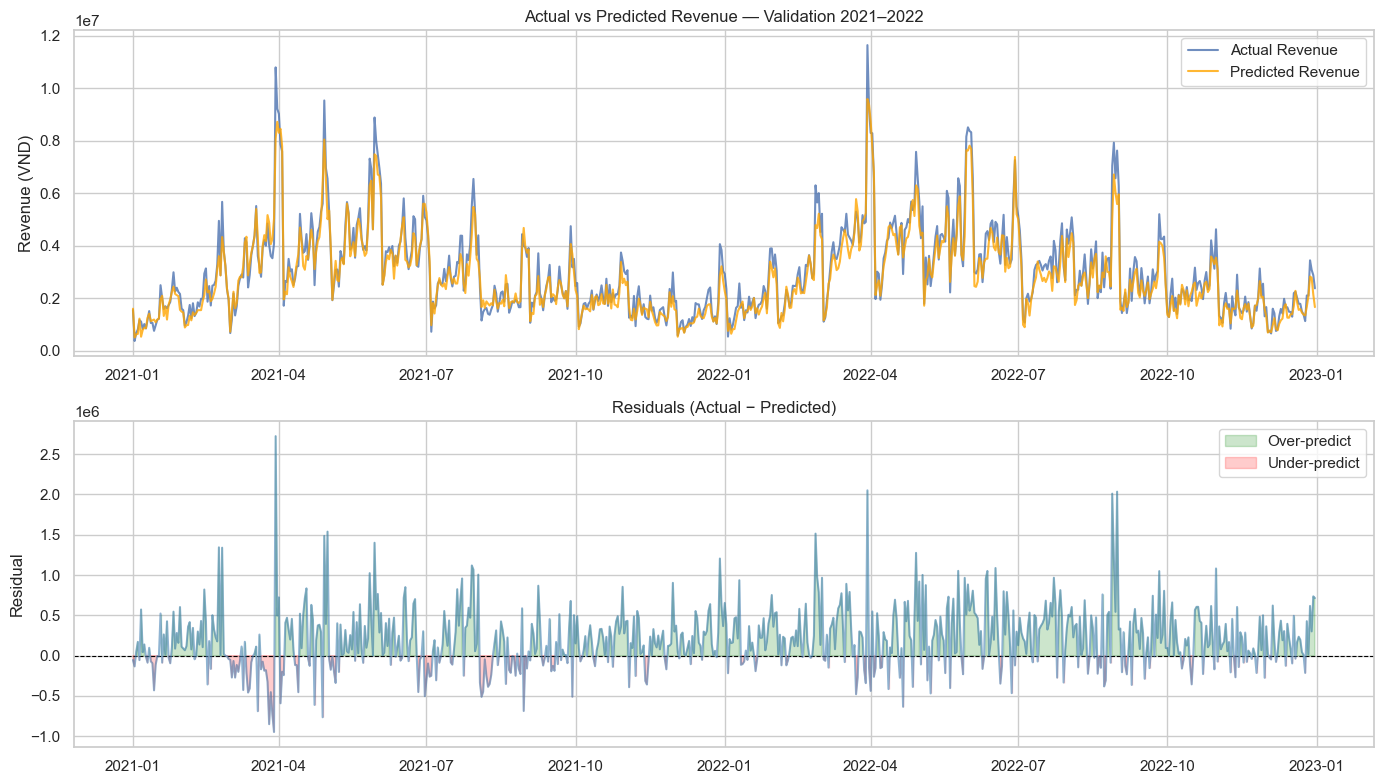

In [53]:
val_dates  = train_clean.loc[val_mask, 'Date']
residuals  = val_actual_rev - val_preds_rev 

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(val_dates, val_actual_rev, label = 'Actual Revenue',    alpha = 0.8)
axes[0].plot(val_dates, val_preds_rev,  label = 'Predicted Revenue', alpha = 0.8, color = 'orange')
axes[0].set_title('Actual vs Predicted Revenue — Validation 2021–2022')
axes[0].legend()
axes[0].set_ylabel('Revenue (VND)')

axes[1].axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
axes[1].plot(val_dates, residuals, color = 'steelblue', alpha = 0.6)
axes[1].fill_between(val_dates, residuals, 0, where = (residuals > 0), color = 'green', alpha = 0.2, label = 'Over-predict')
axes[1].fill_between(val_dates, residuals, 0, where = (residuals < 0), color = 'red', alpha = 0.2, label = 'Under-predict')
axes[1].set_title('Residuals (Actual − Predicted)')
axes[1].set_ylabel('Residual')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8 — Feature Importance & SHAP

- **plot_importance** (gain): feature nào đóng góp nhiều nhất khi tạo split trong cây
- **SHAP**: giải thích định lượng tác động của từng feature lên mỗi dự đoán

#### 8.1 XGBoost Feature Importance (Revenue & COGS)

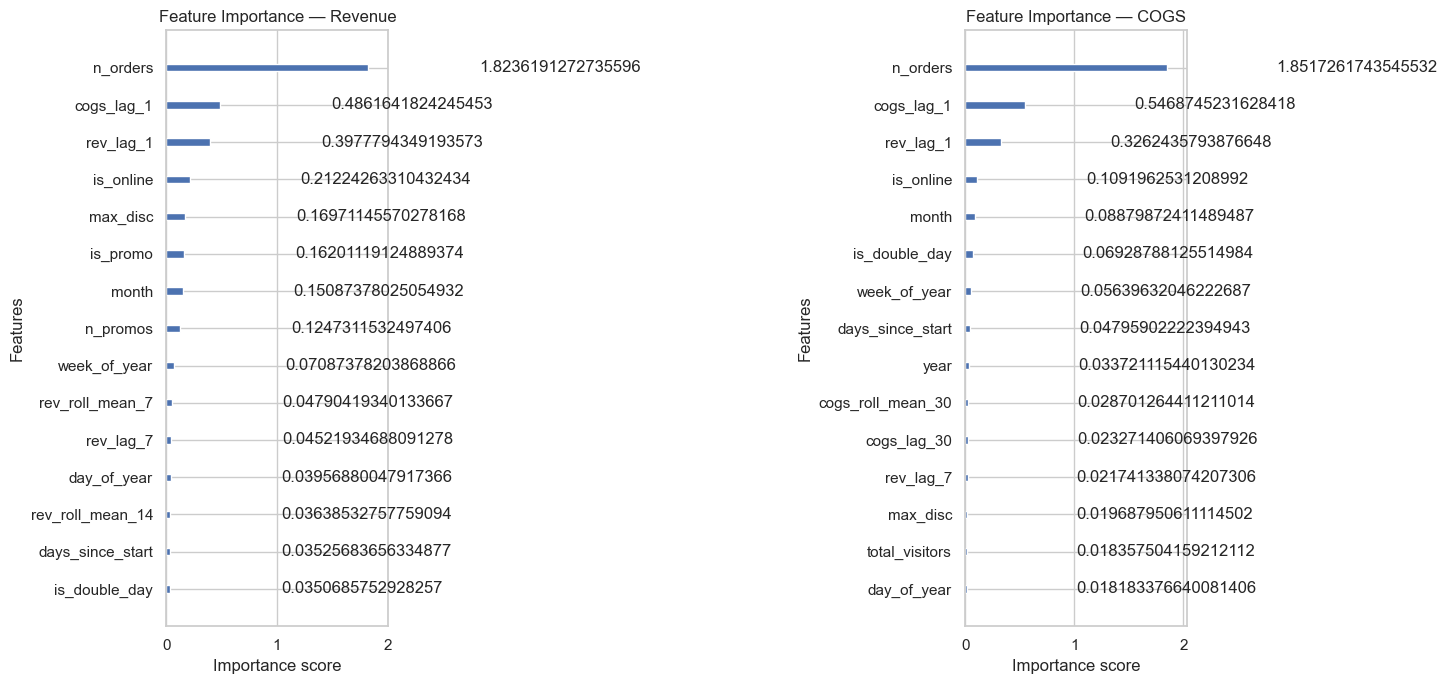

In [54]:
fig, axes = plt.subplots(1, 2, figsize = (16, 7))
plot_importance(model_rev,  ax = axes[0], max_num_features = 15, importance_type = 'gain', title = 'Feature Importance — Revenue')
plot_importance(model_cogs, ax = axes[1], max_num_features = 15, importance_type = 'gain', title = 'Feature Importance — COGS')
plt.tight_layout()
plt.show()

#### 8.2 SHAP Summary Plot (Revenue)

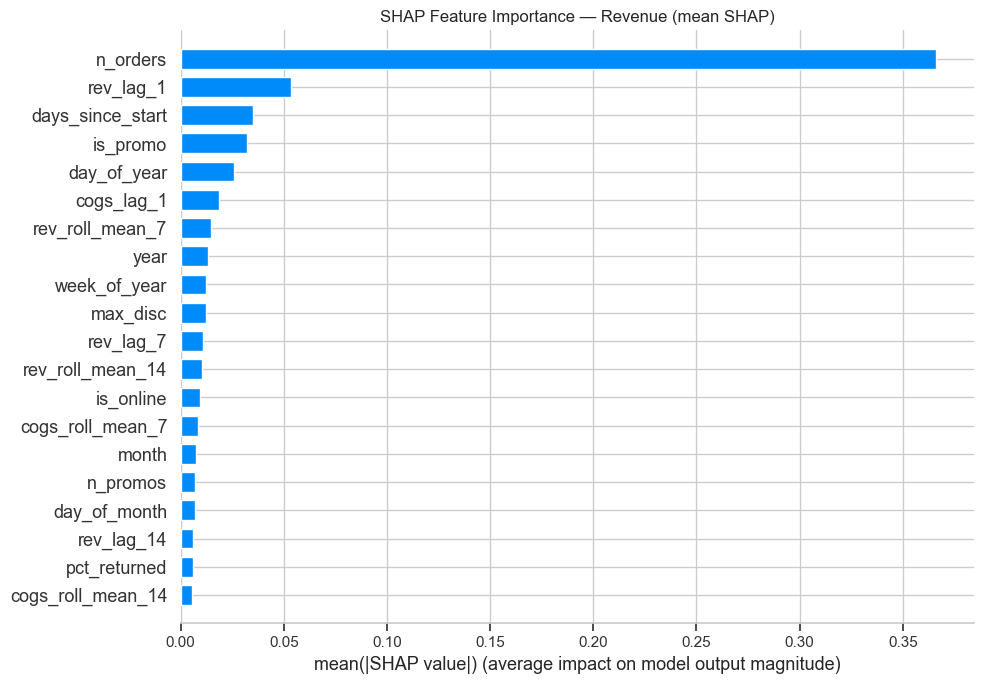

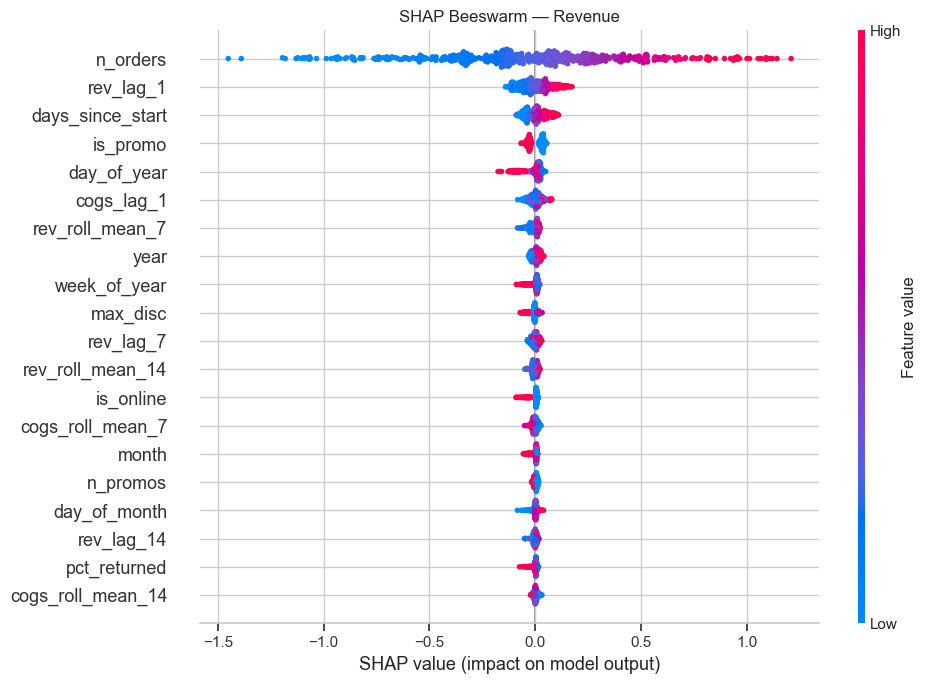

In [55]:
if SHAP_AVAILABLE:
    sample_size = min(500, len(X_train))
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(X_train), size = sample_size, replace = False)
    X_sample = X_train.iloc[sample_idx]

    explainer = shap.TreeExplainer(model_rev)
    shap_values = explainer.shap_values(X_sample)

    # Bar plot — mean SHAP
    plt.figure(figsize = (10, 7))
    shap.summary_plot(shap_values, X_sample, plot_type = 'bar', plot_size = (10, 7), show = False)
    plt.title('SHAP Feature Importance — Revenue (mean SHAP)')
    plt.tight_layout()
    plt.show()

    # Beeswarm — direction + magnitude
    plt.figure(figsize = (10, 7))
    shap.summary_plot(shap_values, X_sample, plot_size = (10, 7), show = False)
    plt.title('SHAP Beeswarm — Revenue')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP not available. Install with: pip install shap')

## 9 — Export Submission

In [56]:
submission = test[['Date','Revenue','COGS']].copy()
submission = submission.merge(
    test_df[['Date','Revenue_pred','COGS_pred']], on = 'Date', how = 'left'
)
submission['Revenue'] = submission['Revenue_pred'].fillna(0)
submission['COGS'] = submission['COGS_pred'].fillna(0)
submission = submission[['Date','Revenue','COGS']]
submission['Date'] = pd.to_datetime(submission['Date']).dt.strftime('%Y-%m-%d')

submission.to_csv('submission.csv', index = False)
print(f"Saved submission.csv — {len(submission):,} rows")
print(submission.head(10).to_string(index = False))

Saved submission.csv — 548 rows
      Date     Revenue        COGS
2023-01-01 529333.3750 467854.5625
2023-01-02 620640.3125 424154.8125
2023-01-03 641617.9375 443034.3125
2023-01-04 636838.5625 466714.6250
2023-01-05 685055.0000 550777.8125
2023-01-06 764969.1875 657160.5625
2023-01-07 776702.3125 675597.4375
2023-01-08 797019.3125 732895.5000
2023-01-09 811903.2500 729955.3750
2023-01-10 778904.6875 719404.3750
